# Unsupervised Methods Together — K-Means + DBSCAN + PCA

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Apply three unsupervised methods to the same 10-customer / 3-feature dataset and compare what each one reveals:
1. **K-means** — fixed-size partition into *k=3* clusters.
2. **DBSCAN** — density-based clusters + noise detection.
3. **PCA** — linear projection to 2D for visualization.

*Heads-up on a footgun in the activity's snippets:* the example code appends `KMeans_Cluster` to `df_scaled` and then re-uses `df_scaled` for DBSCAN and PCA, which would feed the cluster label in as if it were a feature. We keep labels in a separate frame.

## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset

In [2]:
data = {
    'AnnualIncome':  [15, 16, 17, 18, 19, 20, 22, 25, 30, 35],
    'SpendingScore': [39, 81,  6, 77, 40, 76, 94,  5, 82, 56],
    'Age':           [20, 22, 25, 24, 35, 40, 30, 21, 50, 31],
}
df = pd.DataFrame(data)
df

,AnnualIncome,SpendingScore,Age
0,15,39,20
1,16,81,22
2,17,6,25
3,18,77,24
4,19,40,35
5,20,76,40
6,22,94,30
7,25,5,21
8,30,82,50
9,35,56,31


## 4. Preprocess — scale features

In [3]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(features_scaled, columns=df.columns)
df_scaled

,AnnualIncome,SpendingScore,Age
0,-1.086741,-0.546384,-1.074654
1,-0.924540,0.836033,-0.855337
2,-0.762340,-1.632569,-0.526361
3,-0.600140,0.704374,-0.636020
4,-0.437940,-0.513469,0.570225
5,-0.275740,0.671460,1.118518
6,0.048660,1.263924,0.021932
7,0.535260,-1.665483,-0.964996
8,1.346261,0.868948,2.215104
9,2.157261,0.013166,0.131590


In [4]:
# Keep cluster labels separate from the feature matrix
results = pd.DataFrame(index=df.index)

## 5. Task 1 — K-Means (k=3)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
results['KMeans_Cluster'] = kmeans.fit_predict(features_scaled)

print(f'Cluster sizes: {results["KMeans_Cluster"].value_counts().sort_index().to_dict()}')
print(f'WCSS (inertia): {kmeans.inertia_:.4f}')
results

Cluster sizes: {0: 4, 1: 2, 2: 4}
WCSS (inertia): 10.3911


,KMeans_Cluster
0,2
1,0
2,2
3,0
4,2
5,0
6,0
7,2
8,1
9,1


## 6. Task 2 — DBSCAN (eps=0.5, min_samples=2)

The activity asks for these specific parameters. With only 10 points and a tight `eps=0.5` in scaled space, the density requirement is hard to satisfy — most points end up labeled as **noise (-1)**, which is itself instructive.

In [6]:
dbscan = DBSCAN(eps=0.5, min_samples=2)
results['DBSCAN_Cluster'] = dbscan.fit_predict(features_scaled)

n_clusters_db = len(set(results['DBSCAN_Cluster'])) - (1 if -1 in results['DBSCAN_Cluster'].values else 0)
n_noise_db = int((results['DBSCAN_Cluster'] == -1).sum())
print(f'Found {n_clusters_db} cluster(s), {n_noise_db} noise point(s)')
print(f'Cluster sizes: {results["DBSCAN_Cluster"].value_counts().sort_index().to_dict()}')
results

Found 1 cluster(s), 8 noise point(s)
Cluster sizes: {-1: 8, 0: 2}


,KMeans_Cluster,DBSCAN_Cluster
0,2,-1
1,0,0
2,2,-1
3,0,0
4,2,-1
5,0,-1
6,0,-1
7,2,-1
8,1,-1
9,1,-1


## 7. Task 3 — PCA (3D ➜ 2D)

In [7]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(features_scaled)
df_pca = pd.DataFrame(pca_coords, columns=['PCA1', 'PCA2'])

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative variance:      {pca.explained_variance_ratio_.cumsum()}')
df_pca

Explained variance ratio: [0.56964365 0.29865368]
Cumulative variance:      [0.56964365 0.86829732]


,PCA1,PCA2
0,-1.590583,0.322818
1,-0.672455,1.256534
2,-1.576798,-0.723036
3,-0.411679,0.939711
4,-0.104823,-0.114638
5,0.939202,0.662250
6,0.663964,0.922984
7,-1.183198,-1.586920
8,2.664603,-0.275030
9,1.271765,-1.404674


In [8]:
pd.DataFrame(pca.components_, columns=df.columns, index=['PC1', 'PC2']).round(3)

,AnnualIncome,SpendingScore,Age
PC1,0.545,0.493,0.678
PC2,-0.654,0.756,-0.023


## 8. Visualize all three methods together

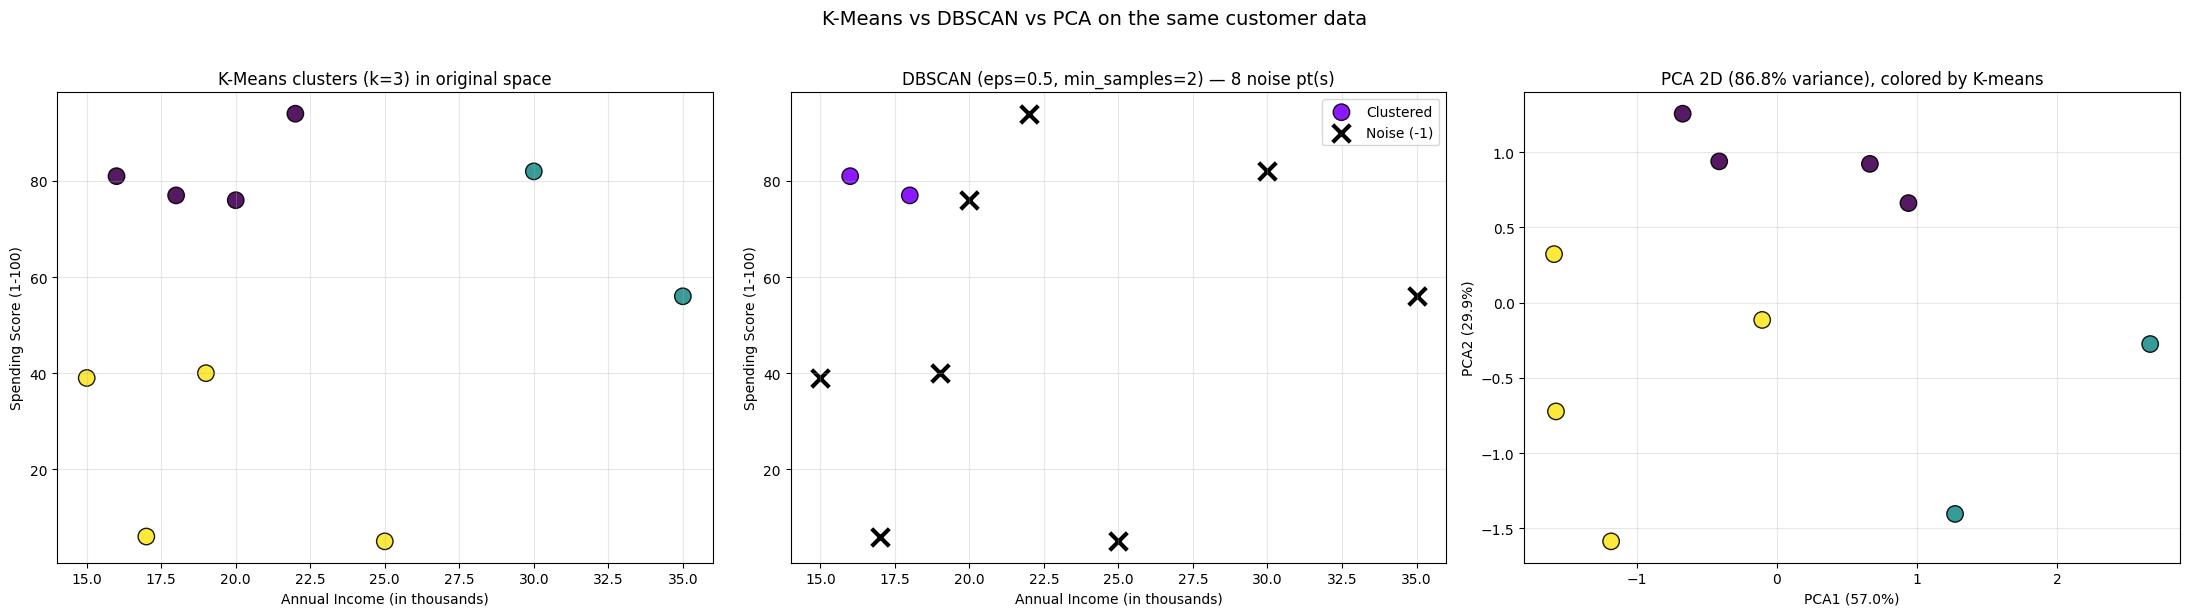

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# K-means in original space
axes[0].scatter(
    df['AnnualIncome'], df['SpendingScore'],
    c=results['KMeans_Cluster'], cmap='viridis',
    s=140, edgecolor='k', alpha=0.9,
)
axes[0].set_title('K-Means clusters (k=3) in original space')
axes[0].set_xlabel('Annual Income (in thousands)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].grid(True, alpha=0.3)

# DBSCAN — noise highlighted
noise_mask = results['DBSCAN_Cluster'] == -1
axes[1].scatter(
    df.loc[~noise_mask, 'AnnualIncome'], df.loc[~noise_mask, 'SpendingScore'],
    c=results.loc[~noise_mask, 'DBSCAN_Cluster'], cmap='rainbow',
    s=140, edgecolor='k', alpha=0.9, label='Clustered',
)
if noise_mask.any():
    axes[1].scatter(
        df.loc[noise_mask, 'AnnualIncome'], df.loc[noise_mask, 'SpendingScore'],
        c='black', marker='x', s=160, linewidths=3, label='Noise (-1)',
    )
axes[1].set_title(f'DBSCAN (eps=0.5, min_samples=2) — {n_noise_db} noise pt(s)')
axes[1].set_xlabel('Annual Income (in thousands)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PCA, colored by K-means cluster
axes[2].scatter(
    df_pca['PCA1'], df_pca['PCA2'],
    c=results['KMeans_Cluster'], cmap='viridis',
    s=140, edgecolor='k', alpha=0.9,
)
axes[2].set_title(f'PCA 2D ({pca.explained_variance_ratio_.sum()*100:.1f}% variance), colored by K-means')
axes[2].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('K-Means vs DBSCAN vs PCA on the same customer data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Interpret the results

### K-means cluster profiles (means per cluster, original units)

In [10]:
df_full = pd.concat([df, results], axis=1)
df_full.groupby('KMeans_Cluster')[['AnnualIncome', 'SpendingScore', 'Age']].mean().round(2)

,AnnualIncome,SpendingScore,Age
KMeans_Cluster,,,
0,19.0,82.0,29.00
1,32.5,69.0,40.50
2,19.0,22.5,25.25


### DBSCAN cluster profiles

In [11]:
df_full.groupby('DBSCAN_Cluster')[['AnnualIncome', 'SpendingScore', 'Age']].mean().round(2)

,AnnualIncome,SpendingScore,Age
DBSCAN_Cluster,,,
-1,22.88,49.75,31.5
0,17.00,79.00,23.0


### Where did the two clusterings agree?

In [12]:
pd.crosstab(results['KMeans_Cluster'], results['DBSCAN_Cluster'],
            rownames=['KMeans'], colnames=['DBSCAN'])

DBSCAN,-1,0
KMeans,,
0,2,2
1,2,0
2,4,0


### Reflection

- **K-means vs DBSCAN.** K-means partitioned all 10 customers into three clean groups: low-income high-spenders, low-income low-spenders, and older mid-to-high-income customers. DBSCAN with the activity's strict parameters (`eps=0.5, min_samples=2`) only formed **one cluster of 2 points** and labeled **8 customers as noise**. The crosstab shows DBSCAN's lone cluster is a subset of K-means cluster 0 (high spenders). On a 10-row dataset with `eps=0.5` in scaled space, DBSCAN is being honest: there genuinely aren't enough dense neighborhoods to form clusters.

- **Outliers and parameter sensitivity.** This activity is a textbook example of DBSCAN's main drawback: it's sensitive to `eps`. Loosening to `eps≈1.0` would form a real cluster; tightening flips more points to noise. The k-distance plot is the standard heuristic for picking `eps` — sort each point's distance to its k-th nearest neighbor and look for the elbow.

- **PCA.** Two principal components capture **~87% of the variance**, which is enough that very little information is lost. PC1 reads as "overall customer scale" (positive loadings on all three features), PC2 contrasts Spending Score against Annual Income.

- **Original space vs PCA space.** The K-means clusters that look distinct in the Income×Spending plot also separate cleanly in the PCA plot — a useful sanity check that the clustering is finding real geometric structure rather than slicing along one feature axis.